<a href="https://www.kaggle.com/code/emmanuelniyioriolowo/data-cleaning-exploration?scriptVersionId=284125603" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# import packages
import numpy as np 
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/ncdc-lassa-fever-timeseries-20202025/lassa_fever_timeseries_minimal.csv
/kaggle/input/ncdc-lassa-fever-timeseries-20202025/lassa_fever_timeseries_full.csv


 # Cleaning 

In [2]:
# read data into a dataframe
df = pd.read_csv('/kaggle/input/ncdc-lassa-fever-timeseries-20202025/lassa_fever_timeseries_minimal.csv')
df

,week_start_date,week_end_date,epi_year,epi_week,suspected_cases,confirmed_cases,deaths
0,2019-12-30,2020-01-05,2020,1,98,18,2
1,2020-01-06,2020-01-12,2020,2,158,64,12
2,2020-01-13,2020-01-19,2020,3,159,81,10
3,2020-01-20,2020-01-26,2020,4,318,95,19
4,2020-01-27,2020-02-02,2020,5,531,104,6
...,...,...,...,...,...,...,...
302,2025-10-13,2025-10-19,2025,42,116,9,1
303,2025-10-20,2025-10-26,2025,43,97,11,1
304,2025-10-27,2025-11-02,2025,44,94,12,1
305,2025-11-03,2025-11-09,2025,45,84,10,1


In [3]:
# construct series dataframe
ts_data = df[['week_end_date', 'confirmed_cases']].copy()
ts_data.columns = ['date', 'confirmed_cases']
ts_data

,date,confirmed_cases
0,2020-01-05,18
1,2020-01-12,64
2,2020-01-19,81
3,2020-01-26,95
4,2020-02-02,104
...,...,...
302,2025-10-19,9
303,2025-10-26,11
304,2025-11-02,12
305,2025-11-09,10


In [4]:
# Ensure datetime index
ts_data['date'] = pd.to_datetime(ts_data['date'])
ts_data = ts_data.set_index('date')
ts_data = ts_data.asfreq('W') # set frequency to weekly
ts_data

,confirmed_cases
date,
2020-01-05,18
2020-01-12,64
2020-01-19,81
2020-01-26,95
2020-02-02,104
...,...
2025-10-19,9
2025-10-26,11
2025-11-02,12


In [5]:
ts_data.describe()

,confirmed_cases
count,307.000000
mean,20.540717
std,25.897753
min,0.000000
25%,6.000000
50%,10.000000
75%,21.000000
max,137.000000


# Exploration 

In [6]:
# create and display plot 
fig =  px.line(ts_data, x=ts_data.index, y="confirmed_cases",
        title="Weekly Lassa Fever Cases (2020–2025)")
fig.show()

## Stationarity 

## ADF test

In [7]:
# ADF test 
def adf_test(series):
    """Using an ADF test to determine if a series in stationary"""
    test_results = adfuller(series)
    print('ADF statistics', test_results[0])
    print('P-Value: ', test_results[1])
    print('Critical Values:')
    for thres, adf_stat in test_results[4].items():
        print('\t%s: %f' % (thres, adf_stat))


adf_test(ts_data['confirmed_cases'])

ADF statistics -6.170389286747824
P-Value:  6.827788672455701e-08
Critical Values:
	1%: -3.452411
	5%: -2.871255
	10%: -2.571947


Going by the ADF test, the series is very stationary, however, by visiual examination of the time series plot, the data exibits seasonality. This is because ADF tests for trend-stationarity but not seasonal-stationarity as seen in the series. 

A better way to test seasonal-stationarity would be to use Decomposition (seasonal decompose) and Autocorrelation 

## Rolling Mean (4 and 8 week windows)

In [8]:
ts_data['rolling_4'] = ts_data['confirmed_cases'].rolling(4).mean()
ts_data['rolling_8'] = ts_data['confirmed_cases'].rolling(8).mean()
ts_data['rolling_std_8'] = ts_data['confirmed_cases'].rolling(8).std()

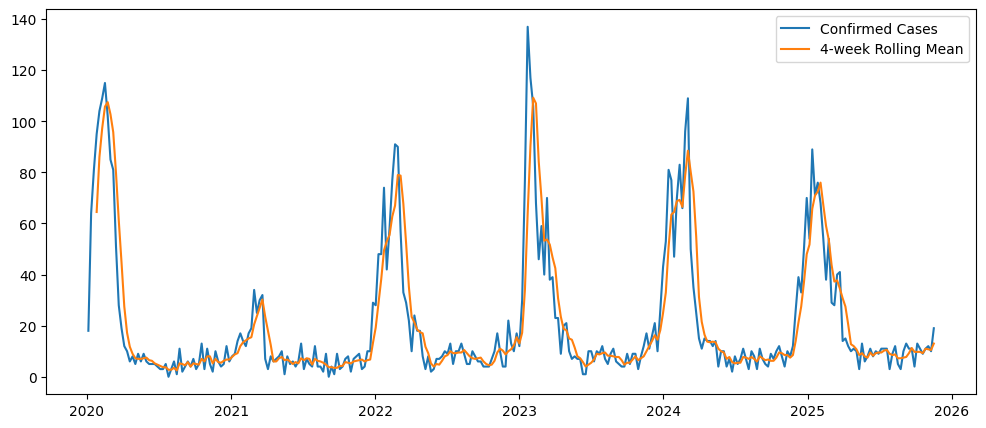

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(ts_data['confirmed_cases'], label='Confirmed Cases')
plt.plot(ts_data['rolling_4'], label='4-week Rolling Mean')
plt.legend()
plt.show()

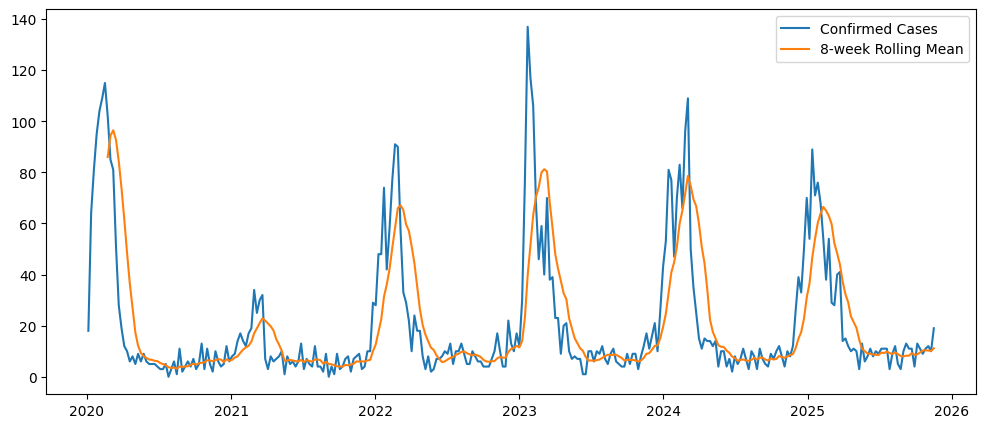

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(ts_data['confirmed_cases'], label='Confirmed Cases')
plt.plot(ts_data['rolling_8'], label='8-week Rolling Mean')
plt.legend()
plt.show()

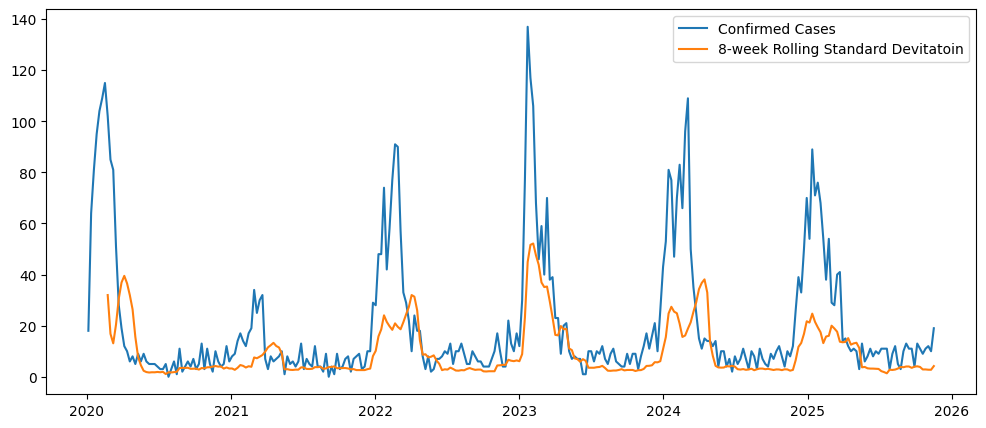

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(ts_data['confirmed_cases'], label='Confirmed Cases')
plt.plot(ts_data['rolling_std_8'], label='8-week Rolling Standard Devitatoin')
plt.legend()
plt.show()

## Decomposition

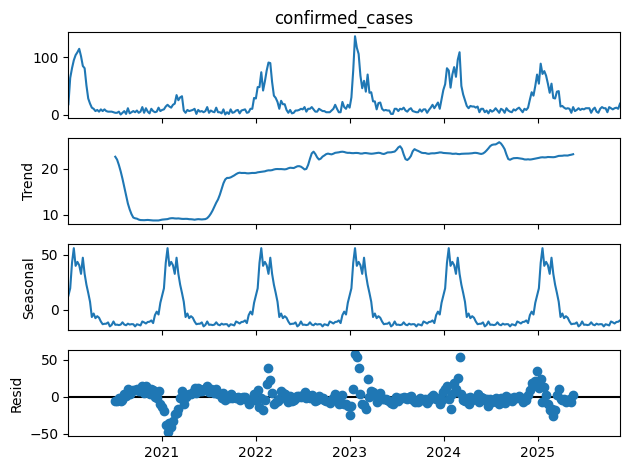

In [12]:
# Plot the decomposition for additive series
decomposition_plot = seasonal_decompose(ts_data['confirmed_cases'], model='additive', period=52)
decomposition_plot.plot()
plt.show()

Seasonal Decomposition Findings

A seasonal decomposition using a 52-week period revealed a strong and highly regular annual seasonal pattern in the confirmed Lassa fever case data. Seasonal peaks occurred consistently at the same time each year, while troughs aligned with the wet season, indicating stable seasonal cycles. The trend component showed an initial decline followed by a gradual rise and eventual stabilization, suggesting changes in early reporting or outbreak intensity but no long-term upward or downward trend overall. The residual component consisted mostly of short-term irregular fluctuations with occasional positive spikes corresponding to outbreak clusters.
Overall, this decomposition indicates that seasonality is the dominant structure in the series, while trend is relatively weak. As a result, seasonal models such as SARIMA (with a 52-week period) or models using explicit seasonal terms are expected to perform best.

In [13]:
# Run STL
stl = STL(ts_data['confirmed_cases'], seasonal=53, robust=True) 
result = stl.fit()

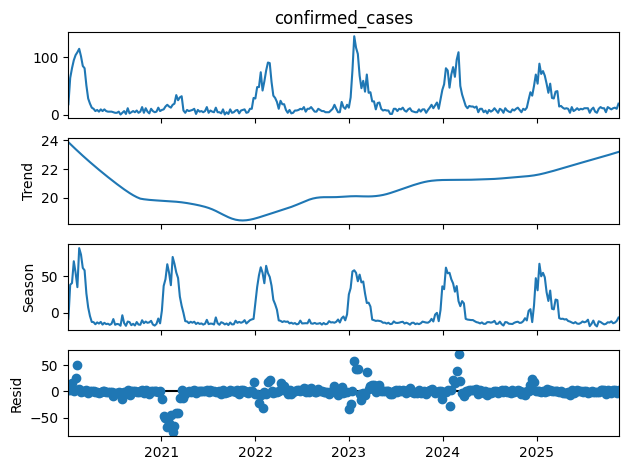

In [14]:
result.plot()
plt.show()

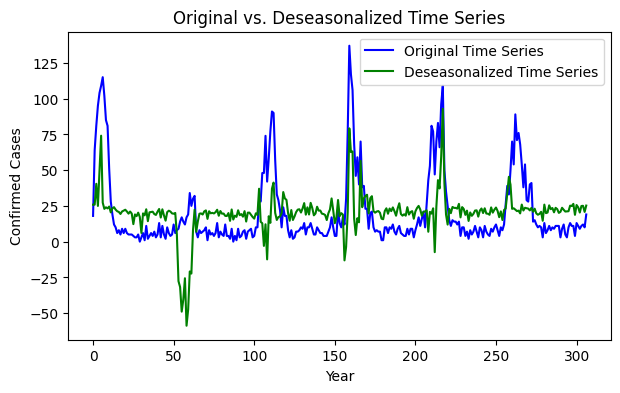

In [15]:
# Create a deseasonalized time series
deseasonalized_series = ts_data['confirmed_cases'] - result.seasonal

# visualize the comparative plot
plt.figure(figsize=(7, 4))
plt.plot(df.index, ts_data['confirmed_cases'], label='Original Time Series', color='blue')
plt.plot(df.index, deseasonalized_series, label='Deseasonalized Time Series', color='green')
plt.title('Original vs. Deseasonalized Time Series')
plt.xlabel('Year')
plt.ylabel('Confirmed Cases')
plt.legend()
plt.show()

## Autocorrelation (ACF)

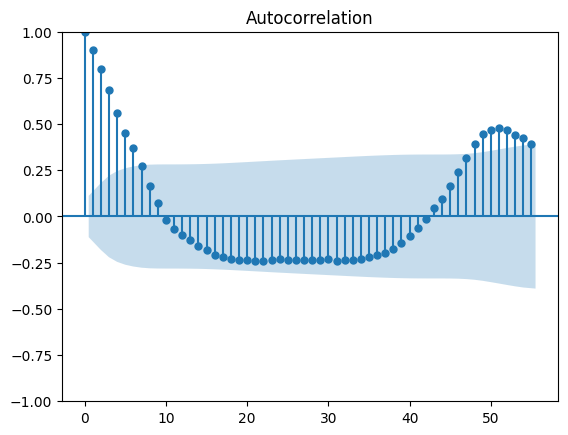

In [16]:
# acf plotting with entier series 
plot_acf(ts_data['confirmed_cases'], lags=55)
plt.show()

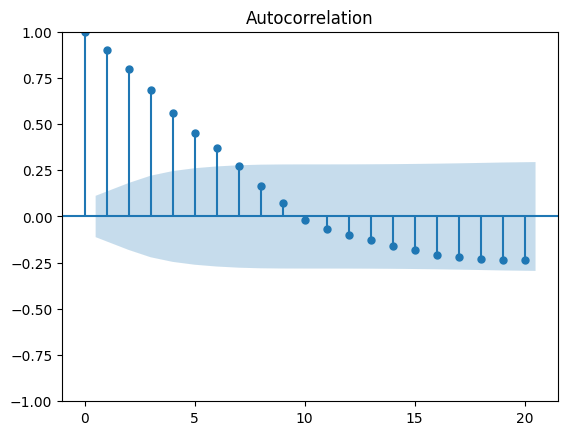

In [17]:
# plot autocorrelation at 52 weeks for better visualization 
plot_acf(ts_data['confirmed_cases'], lags=20)
plt.show()

## Partial Autocorrelation (PACF)

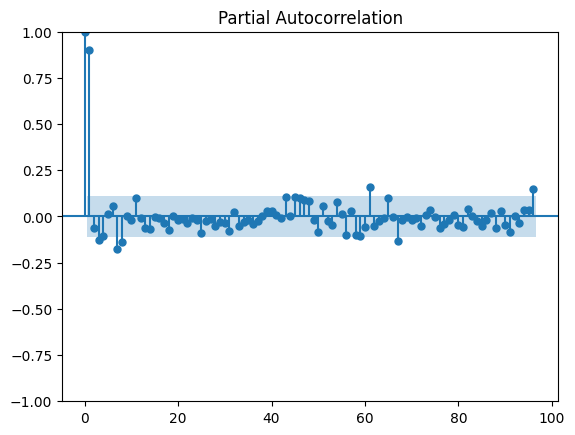

In [18]:
# pacf plotting with entier series 
plot_pacf(ts_data['confirmed_cases'], lags=96)
plt.show()

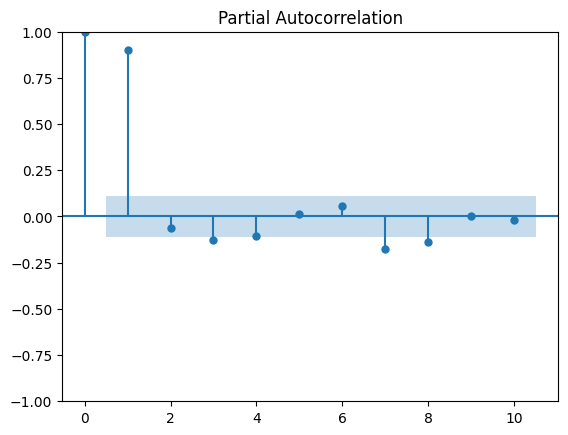

In [19]:
# plot autocorrelation at 52 weeks for better visualization 
plot_pacf(ts_data['confirmed_cases'], lags=10)
plt.show()

The ACF plot exhibits a generally oscillating pattern, indicating seasonality, with peaks and troughs gradually decaying toward zero. The first and second peaks are statistically significant, and the autocorrelations become insignificant starting at lag 7.

SARIMA Orders based on ACF and PACF

Non-Seasonal:
- p = 1 (significant spike at lag 1 with subsequent lags)
- q = 0 (ACF tapers)
- d = 1 (A slow decay form high values on ACF plot)

Seasonal:
- P = 0 (No significant spike at lags 52 or 53)
- Q = 1 (Significant spike at lag 42)
- D = 1 (U shaped ACF)
- s = 52

# Summary
Exploration and Evaluation

Cleaning
The initial dataset was read from the CSV file and loaded into a dataframe. The series for analysis was then created by selecting the week-end date (renamed to date) and the corresponding confirmed cases. The date column was standardized and set as the index.

There were 307 weeks of reported confirmed cases, with no missing values. Confirmed cases had a mean of 20.57 and a standard deviation of 25, with maximum and minimum values of 137 and 0, respectively.

The series was visualized by plotting confirmed cases against time, revealing a clear seasonal pattern but no recognizable long-term trend.

Trend stationarity was then assessed using the ADF test, which confirmed that the series was trend-stationary.

Seasonal stationarity was explored by plotting rolling means (4-week and 8-week windows) and a rolling standard deviation. These revealed a clearer seasonal pattern that appeared additive in nature.

Following this, the components of the series were isolated using additive seasonal decomposition. This revealed a strong and highly regular annual seasonal pattern in confirmed Lassa fever cases. Seasonal peaks appeared consistently at the same time each year, while troughs aligned with the wet season, indicating stable seasonal cycles.

The trend component showed an initial decline, followed by a gradual rise and eventual stabilization—suggesting shifts in reporting or outbreak intensity, but no overall upward or downward long-term trend.

The residual component mostly consisted of short-term irregular fluctuations, with occasional positive spikes corresponding to outbreak clusters.

Overall, the decomposition indicates that seasonality is the dominant structure in the series, while the trend is relatively weak.

An autocorrelation plot (ACF) was also generated to further examine temporal dependence in the data. SARIMA(1,1,0)(0,1,1,52)